# FastKAN-AD + DeepSVDD Hybrid on SWaT with Alpha Tuning and EasyTSAD Evaluation

This notebook rebuilds the holdout-tuned hybrid model with DeepSVDD built on FastKANAD latent features using an **RBF / FastKAN-style KAN-AD backbone** instead of the original Fourier KAN-AD backbone.

## What stays the same
- SWaT **holdout** setup:
  - original SWaT **train** stays as train
  - the **first anomalous part of the original test** is used as a **calibration split** for alpha tuning
  - the **remaining test tail** becomes the final EasyTSAD test set
- Final anomaly score:

\[
s_t = \alpha \cdot \sigma(z(E_t)) + (1-\alpha) \cdot \sigma(z(D_t))
\]

where:
- \(E_t\): prediction error
- \(D_t\): DeepSVDD distance
- \(z(\cdot)\): z-score using **train-only** statistics
- \(\sigma\): sigmoid

## What changes
- The KAN-AD forecasting branch now uses an **RBF family function** (FastKAN-style) instead of the original Fourier family.

## Final workflow
1. Install repos and EasyTSAD
2. Build a custom SWaT holdout dataset on disk
3. Train the FastKAN-AD + DeepSVDD hybrid model with DeepSVDD built on FastKANAD latent features
4. Tune **alpha** on the calibration split
5. Run final evaluation on the holdout test split with EasyTSAD


In [ ]:

# Cell 1 — Install dependencies and clone repositories

!pip install --upgrade pip
!pip install torch torchinfo tqdm numpy scikit-learn matplotlib pandas toml

!rm -rf /content/KAN-AD
!rm -rf /content/datasets

!git clone https://github.com/CSTCloudOps/KAN-AD.git /content/KAN-AD
!git clone https://github.com/CSTCloudOps/datasets.git /content/datasets

!rm -rf /content/KAN-AD/datasets
!mv /content/datasets /content/KAN-AD/datasets

%cd /content/KAN-AD

Cloning into '/content/KAN-AD'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 1), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 61.77 KiB | 5.15 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Cloning into '/content/datasets'...
remote: Enumerating objects: 4503, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 4503 (delta 2), reused 0 (delta 0), pack-reused 4496 (from 3)
Receiving objects: 100% (4503/4503), 262.52 MiB | 17.22 MiB/s, done.
Resolving deltas: 100% (1962/1962), done.
Updating files: 100% (5564/5564), done.
/content/KAN-AD


In [ ]:

# Cell 2 — Install EasyTSAD, fix import syntax issue, and configure paths

!pip install git+https://github.com/CSTCloudOps/EasyTSAD.git
!sed -i 's/TSData,*/TSData/g' /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py || true
!grep -n "TSData" /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py | head -n 20

import os
import sys
import glob

REPO_ROOT = "/content/KAN-AD"
DATA_ROOT = "/content/KAN-AD/datasets"

sys.path.insert(0, REPO_ROOT)

candidates = glob.glob("/content/KAN-AD/**/kanad/kanad.py", recursive=True)
print("Found KAN-AD candidates:", candidates)
assert candidates, "Could not find kanad/kanad.py inside the cloned KAN-AD repo."

KANAD_PY = sorted(candidates, key=len)[0]
KANAD_PKG_DIR = os.path.dirname(KANAD_PY)
KANAD_ROOT_DIR = os.path.dirname(KANAD_PKG_DIR)

sys.path.insert(0, KANAD_ROOT_DIR)

print("KANAD_PKG_DIR =", KANAD_PKG_DIR)
print("KANAD_ROOT_DIR =", KANAD_ROOT_DIR)
print("sys.path[:4] =", sys.path[:4])

  Cloning https://github.com/CSTCloudOps/EasyTSAD.git to /tmp/pip-req-build-c4oz0iz6
  Running command git clone --filter=blob:none --quiet https://github.com/CSTCloudOps/EasyTSAD.git /tmp/pip-req-build-c4oz0iz6
  Resolved https://github.com/CSTCloudOps/EasyTSAD.git to commit a4f3f5187566300a5f661595a4365ee47b83f577
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
1:from .TSData import TSData
2:from .MTSData import MTSData
Found KAN-AD candidates: ['/content/KAN-AD/kanad/kanad.py']
KANAD_PKG_DIR = /content/KAN-AD/kanad
KANAD_ROOT_DIR = /content/KAN-AD
sys.path[:4] = ['/content/KAN-AD', '/content/KAN-AD', '/content', '/env/python']


In [ ]:

# Cell 3 — Imports and sanity check

import json
import math
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

from torch.utils.data import Dataset, DataLoader

from EasyTSAD.Controller import TSADController
from EasyTSAD.DataFactory import TSData
from EasyTSAD.Methods import BaseMethod
from EasyTSAD.Evaluations.Protocols import (
    EventF1PA,
    PointF1PA,
    PointKthF1PA,
    PointAuprcPA,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("TSADController imported:", TSADController)


Device: cuda
TSADController imported: <class 'EasyTSAD.Controller.TSADController.TSADController'>


In [ ]:

# Cell 4 — Define the FastKAN-style RBF KAN-AD backbone helpers

class PeriodicIndexBasisLayer(nn.Module):
    """
    Index-based periodic basis retained from the KAN-AD family:
        sin(2*pi*n*i/T), cos(2*pi*n*i/T)
    """

    def __init__(self, order: int, window: int):
        super().__init__()
        self.order = int(order)
        self.window = int(window)
        idx = torch.arange(self.window, dtype=torch.float32)
        self.register_buffer("idx", idx)

    def forward(self, x):
        B, W = x.shape
        feats = []
        t = self.idx.to(x.device)
        for n in range(1, self.order + 1):
            feats.append(torch.sin(2.0 * math.pi * n * t / self.window).view(1, 1, W).repeat(B, 1, 1))
            feats.append(torch.cos(2.0 * math.pi * n * t / self.window).view(1, 1, W).repeat(B, 1, 1))
        return torch.cat(feats, dim=1) if feats else torch.empty(B, 0, W, device=x.device)


class GaussianRBFLayer(nn.Module):
    """
    Gaussian radial basis family (FastKAN-style).
    """

    def __init__(self, num_centers: int, sigma: float = 1.0):
        super().__init__()
        self.num_centers = int(num_centers)
        self.sigma = float(sigma)
        centers = torch.linspace(-1, 1, self.num_centers)
        self.register_buffer("centers", centers)

    def forward(self, x):
        x = x.unsqueeze(1)
        c = self.centers.view(1, -1, 1)
        return torch.exp(-((x - c) ** 2) / (self.sigma ** 2 + 1e-8))


class FastKANADModel(nn.Module):
    """
    FastKAN-style KAN-AD backbone.

    Mapping channels:
      - RBF family basis channels
      - periodic index basis channels
      - raw input channel

    Reducing:
      - Conv1d + BN + GELU
      - Conv1d + residual + BN + GELU
      - 1x1 projection + residual + BN + GELU

    Projection:
      - final temporal Conv1d over the full window
    """

    def __init__(
        self,
        window: int,
        order: int = 2,
        family_channels: int = None,
        sigma: float = 0.75,
    ):
        super().__init__()

        self.window = int(window)
        self.order = int(order)

        if family_channels is None:
            family_channels = 4
        self.family_channels = int(family_channels)

        self.family_layer = GaussianRBFLayer(num_centers=self.family_channels, sigma=sigma)
        self.family_out_channels = self.family_channels

        self.periodic_layer = PeriodicIndexBasisLayer(order=self.order, window=self.window)
        self.periodic_out_channels = 2 * self.order

        self.channels = self.family_out_channels + self.periodic_out_channels + 1

        self.init_conv = nn.Conv1d(self.channels, self.channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.inner_conv = nn.Conv1d(self.channels, self.channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.out_conv = nn.Conv1d(self.channels, 1, kernel_size=1, bias=False)
        self.final_conv = nn.Conv1d(1, 1, kernel_size=self.window, stride=1, padding=0, bias=True)

        self.bn1 = nn.BatchNorm1d(self.channels)
        self.bn2 = nn.BatchNorm1d(self.channels)
        self.bn3 = nn.BatchNorm1d(1)
        self.act = nn.GELU()

    def forward_feature(self, x: torch.Tensor):
        raw = x.unsqueeze(1)
        family = self.family_layer(x)
        periodic = self.periodic_layer(x)

        ff = torch.cat([family, periodic, raw], dim=1)
        res0 = raw
        res1 = ff

        ff = self.act(self.bn1(self.init_conv(ff)))
        ff = self.act(self.bn2(self.inner_conv(ff) + res1))
        ff = self.act(self.bn3(self.out_conv(ff) + res0))
        return ff

    def forward_head(self, ff: torch.Tensor):
        return self.final_conv(ff).squeeze(1)

    def forward(self, x: torch.Tensor):
        ff = self.forward_feature(x)
        return self.forward_head(ff)

print("FastKANADModel ready.")


FastKANADModel ready.


In [ ]:
# Cell 5 — Build SWaT holdout dataset + save calibration arrays outside EasyTSAD tree

import os
import shutil
import numpy as np

# -----------------------------
# Basic paths / names
# -----------------------------
ROOT_DIR = "/content/KAN-AD"
DATA_ROOT = os.path.join(ROOT_DIR, "datasets", "MTS")
ORIG_DATASET = "SWaT"
CUSTOM_DATASET = "SWaT_HybridHoldout"

orig_curve_dir = os.path.join(DATA_ROOT, ORIG_DATASET, "AllInOne")
custom_dataset_dir = os.path.join(DATA_ROOT, CUSTOM_DATASET)
custom_curve_dir = os.path.join(custom_dataset_dir, "AllInOne")

print("Original SWaT curve dir:", orig_curve_dir)

# -----------------------------
# Load original SWaT arrays
# -----------------------------
train = np.load(os.path.join(orig_curve_dir, "train.npy"))
test = np.load(os.path.join(orig_curve_dir, "test.npy"))

train_label_path = os.path.join(orig_curve_dir, "train_label.npy")
test_label_path = os.path.join(orig_curve_dir, "test_label.npy")

if os.path.exists(train_label_path):
    train_label = np.load(train_label_path)
else:
    train_label = np.zeros(len(train), dtype=np.int64)

if os.path.exists(test_label_path):
    test_label = np.load(test_label_path)
else:
    raise FileNotFoundError(f"Missing test labels: {test_label_path}")

print("train shape:", train.shape)
print("test shape :", test.shape)
print("train_label shape:", train_label.shape, " positives:", int(train_label.sum()))
print("test_label shape :", test_label.shape, " positives:", int(test_label.sum()))

# -----------------------------
# Choose calibration split from the beginning of labeled test
# Goal: have a labeled calibration set with anomalies for alpha tuning
# -----------------------------
test_len = len(test)
default_calib_end = int(0.20 * test_len)  # first 20% of test

# Ensure calibration contains anomalies; if not, extend until it does
positive_idx = np.where(test_label > 0)[0]
if len(positive_idx) == 0:
    raise ValueError("SWaT test labels contain no anomalies; cannot build calibration split.")

first_pos = int(positive_idx[0])
last_pos = int(positive_idx[min(len(positive_idx) - 1, max(0, int(0.10 * len(positive_idx))))])

calib_end = max(default_calib_end, last_pos + 1)
calib_end = min(calib_end, test_len - 1)

calib_arr = test[:calib_end].copy()
calib_label = test_label[:calib_end].copy()

final_test = test[calib_end:].copy()
final_test_label = test_label[calib_end:].copy()

print("\nChosen calibration end index:", calib_end)
print("Calibration shape:", calib_arr.shape, " positives:", int(calib_label.sum()))
print("Final test shape :", final_test.shape, " positives:", int(final_test_label.sum()))

if calib_label.sum() == 0:
    raise ValueError("Calibration split still has no anomalies. Increase calibration size.")

# -----------------------------
# Remove old broken dataset tree if it exists
# -----------------------------
if os.path.exists(custom_dataset_dir):
    shutil.rmtree(custom_dataset_dir)

os.makedirs(custom_curve_dir, exist_ok=True)

# Save EasyTSAD dataset files
np.save(os.path.join(custom_curve_dir, "train.npy"), train)
np.save(os.path.join(custom_curve_dir, "train_label.npy"), train_label)
np.save(os.path.join(custom_curve_dir, "test.npy"), final_test)
np.save(os.path.join(custom_curve_dir, "test_label.npy"), final_test_label)

# Optional metadata copy if original files exist
for extra_name in ["info.json", "meta.json"]:
    src = os.path.join(orig_curve_dir, extra_name)
    dst = os.path.join(custom_curve_dir, extra_name)
    if os.path.exists(src):
        shutil.copy2(src, dst)

# -----------------------------
# Save calibration arrays OUTSIDE EasyTSAD dataset tree
# -----------------------------
RUNTIME_DIR = os.path.join(ROOT_DIR, "kanad_runtime")
os.makedirs(RUNTIME_DIR, exist_ok=True)

CALIB_DIR = os.path.join(RUNTIME_DIR, f"{CUSTOM_DATASET}_calibration")
if os.path.exists(CALIB_DIR):
    shutil.rmtree(CALIB_DIR)
os.makedirs(CALIB_DIR, exist_ok=True)

np.save(os.path.join(CALIB_DIR, "calib.npy"), calib_arr)
np.save(os.path.join(CALIB_DIR, "calib_label.npy"), calib_label)

# -----------------------------
# Sanity checks
# -----------------------------
print("\nCreated EasyTSAD dataset at:", custom_curve_dir)
print("Saved files:", sorted(os.listdir(custom_curve_dir)))

print("\nCalibration dir:", CALIB_DIR)
print("Calibration files:", sorted(os.listdir(CALIB_DIR)))

assert os.path.exists(os.path.join(custom_curve_dir, "train.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "test.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "test_label.npy"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib.npy"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib_label.npy"))

print("\nCell 5 completed successfully.")

Original SWaT curve dir: /content/KAN-AD/datasets/MTS/SWaT/AllInOne
train shape: (473399, 51)
test shape : (449919, 51)
train_label shape: (473399,)  positives: 0
test_label shape : (449919,)  positives: 54621

Chosen calibration end index: 92183
Calibration shape: (92183, 51)  positives: 5463
Final test shape : (357736, 51)  positives: 49158

Created EasyTSAD dataset at: /content/KAN-AD/datasets/MTS/SWaT_HybridHoldout/AllInOne
Saved files: ['info.json', 'test.npy', 'test_label.npy', 'train.npy', 'train_label.npy']

Calibration dir: /content/KAN-AD/kanad_runtime/SWaT_HybridHoldout_calibration
Calibration files: ['calib.npy', 'calib_label.npy']

Cell 5 completed successfully.


In [ ]:

# Cell 6 — Utility functions: segmentation, calibration F1 search, normalization, plotting

def contiguous_segments(binary_labels: np.ndarray):
    y = np.asarray(binary_labels).astype(int)
    segs = []
    start = None
    for i, v in enumerate(y):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            segs.append((start, i - 1))
            start = None
    if start is not None:
        segs.append((start, len(y) - 1))
    return segs


def segment_overlap(a, b):
    return not (a[1] < b[0] or b[1] < a[0])


def event_f1_from_binary(pred_binary: np.ndarray, true_binary: np.ndarray):
    gt_segs = contiguous_segments(true_binary)
    pr_segs = contiguous_segments(pred_binary)

    if len(gt_segs) == 0 and len(pr_segs) == 0:
        return 1.0, 1.0, 1.0
    if len(gt_segs) == 0:
        return 0.0, 0.0, 0.0
    if len(pr_segs) == 0:
        return 0.0, 0.0, 0.0

    used_pr = set()
    tp = 0
    for gt in gt_segs:
        for j, pr in enumerate(pr_segs):
            if j in used_pr:
                continue
            if segment_overlap(gt, pr):
                tp += 1
                used_pr.add(j)
                break

    precision = tp / max(len(pr_segs), 1)
    recall = tp / max(len(gt_segs), 1)
    f1 = 0.0 if (precision + recall == 0) else 2 * precision * recall / (precision + recall)
    return f1, precision, recall


def best_event_f1_threshold(scores: np.ndarray, labels: np.ndarray, n_grid: int = 200):
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels).astype(int)

    if labels.sum() == 0:
        return 0.0, float(np.max(scores)), 0.0, 0.0

    lo = float(np.min(scores))
    hi = float(np.max(scores))

    if not np.isfinite(lo) or not np.isfinite(hi):
        raise ValueError("Non-finite scores encountered during threshold search.")

    if hi <= lo:
        pred = (scores > lo).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        return f1, lo, p, r

    thresholds = np.linspace(lo, hi, n_grid)
    best = (-1.0, lo, 0.0, 0.0)

    for thr in thresholds:
        pred = (scores > thr).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        if f1 > best[0]:
            best = (f1, float(thr), float(p), float(r))

    return best


def sigmoid_np(x):
    x = np.clip(x, -8.0, 8.0)
    return 1.0 / (1.0 + np.exp(-x))


def zscore_sigmoid(x, mu, std, eps=1e-8):
    z = (x - mu) / (std + eps)
    return sigmoid_np(z)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def show_overlay(scores, labels, title, max_points=4000):
    n = min(len(scores), max_points)
    x = np.arange(n)
    plt.figure(figsize=(14, 4))
    plt.plot(x, scores[:n], label="score")
    if labels is not None and n > 0:
        ymax = max(1e-6, float(np.max(scores[:n])))
        plt.fill_between(x, 0, ymax, where=labels[:n].astype(bool), alpha=0.2, step="pre", label="anomaly")
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:

# Cell 7 — Window datasets for train/valid/test and calibration

class MTSWindowDataset(Dataset):
    def __init__(self, tsData, phase, window_size):
        self.window_size = int(window_size)

        if phase == "train":
            self.data = np.asarray(tsData.train)
        elif phase == "valid":
            self.data = np.asarray(tsData.valid)
        elif phase == "test":
            self.data = np.asarray(tsData.test)
        else:
            raise ValueError("phase must be train / valid / test")

        assert self.data.ndim == 2, f"Expected 2D MTS array, got {self.data.shape}"
        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


class ArrayWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, labels: np.ndarray, window_size: int):
        self.data = np.asarray(data)
        self.labels = np.asarray(labels).astype(int)
        self.window_size = int(window_size)

        assert self.data.ndim == 2, f"Expected 2D array, got {self.data.shape}"
        assert len(self.data) == len(self.labels), "Data/label length mismatch"

        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        label = self.labels[idx + self.window_size]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long),
        )

print("Datasets ready.")

Datasets ready.


In [ ]:

# Cell 8 — Define the shared-latent hybrid model with alpha tuning on calibration data

class FastKANAD_SharedLatentSVDD_AlphaTuned_Holdout(BaseMethod):
    """
    Hybrid anomaly detector (V2):
      - FastKANAD forecasting branch
      - DeepSVDD built on the latent representation produced by FastKANAD

    Final anomaly score:
      score = alpha * pred_norm + (1 - alpha) * svdd_norm

    where pred_norm and svdd_norm are computed with:
      z-score -> sigmoid

    Compared with V1:
      - SVDD no longer uses a separate heavy branch unrelated to FastKANAD
      - SVDD operates on FastKANAD latent features
      - the extra head is reduced to a light projection for stability
    """

    def __init__(self, params: dict) -> None:
        super().__init__()
        self.__anomaly_score = None

        self.batch_size = int(params["batch_size"])
        self.window = int(params["window"])
        self.order = int(params["order"])
        self.epochs = int(params["epochs"])
        self.lr = float(params["lr"])

        self.lambda_svdd = float(params.get("lambda_svdd", 0.1))
        self.emb_dim = int(params.get("emb_dim", 32))
        self.patience = int(params.get("patience", 6))

        self.family_channels = int(params.get("family_channels", 4))
        self.sigma = float(params.get("sigma", 0.75))

        self.alpha_grid = params.get("alpha_grid", [round(i / 10.0, 2) for i in range(11)])
        self.calib_data_path = params["calib_data_path"]
        self.calib_label_path = params["calib_label_path"]

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = FastKANADModel(
            window=self.window,
            order=self.order,
            family_channels=self.family_channels,
            sigma=self.sigma,
        ).to(self.device)

        # Shared-latent SVDD projection head:
        # ff from FastKANAD forward_feature has shape (B*F, 1, window)
        # we project the latent vector of length 'window' to a small embedding.
        self.svdd_proj = nn.Sequential(
            nn.Linear(self.window, self.emb_dim),
            nn.GELU(),
        ).to(self.device)

        self.optimizer = optim.Adam(
            list(self.model.parameters()) + list(self.svdd_proj.parameters()),
            lr=self.lr
        )
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=5, gamma=0.75)
        self.loss = nn.MSELoss()

        self.center = None
        self.pred_mu = None
        self.pred_std = None
        self.svdd_mu = None
        self.svdd_std = None
        self.best_alpha = None
        self.best_valid_f1 = None
        self.tuned_threshold = None
        self.alpha_history = []

    @staticmethod
    def _sigmoid_np(x: np.ndarray) -> np.ndarray:
        x = np.clip(x, -50, 50)
        return 1.0 / (1.0 + np.exp(-x))

    @staticmethod
    def _safe_std(x: np.ndarray) -> float:
        return float(np.std(x) + 1e-8)

    def _latent_project(self, ff: torch.Tensor) -> torch.Tensor:
        feat = ff.squeeze(1)              # (B*F, window)
        return self.svdd_proj(feat)       # (B*F, emb_dim)

    def _loader_components(self, loader):
        pred_list = []
        svdd_list = []

        self.model.eval()
        self.svdd_proj.eval()

        with torch.no_grad():
            for x, target in loader:
                x = x.to(self.device)
                target = target.to(self.device)

                B, W, F = x.shape
                x_1d = x.permute(0, 2, 1).reshape(B * F, W)
                t_1d = target.reshape(B * F, 1)

                ff = self.model.forward_feature(x_1d)
                out = self.model.forward_head(ff)

                pred_err = (out - t_1d).abs().reshape(B, F).max(dim=1).values

                z = self._latent_project(ff).reshape(B, F, -1).mean(dim=1)
                svdd = ((z - self.center) ** 2).sum(dim=1)

                pred_list.append(pred_err.detach().cpu())
                svdd_list.append(svdd.detach().cpu())

        pred_arr = torch.cat(pred_list).numpy()
        svdd_arr = torch.cat(svdd_list).numpy()
        return pred_arr, svdd_arr

    def _normalize_components(self, pred_arr: np.ndarray, svdd_arr: np.ndarray):
        pred_z = (pred_arr - self.pred_mu) / self.pred_std
        svdd_z = (svdd_arr - self.svdd_mu) / self.svdd_std
        pred_norm = self._sigmoid_np(pred_z)
        svdd_norm = self._sigmoid_np(svdd_z)
        return pred_norm, svdd_norm

    @staticmethod
    def _best_f1_threshold(scores: np.ndarray, labels: np.ndarray):
        scores = np.asarray(scores, dtype=np.float64)
        labels = np.asarray(labels).astype(np.int32)

        if len(scores) == 0:
            return 0.0, 0.0

        order = np.argsort(scores)[::-1]
        sorted_scores = scores[order]
        sorted_labels = labels[order]

        total_pos = int(sorted_labels.sum())
        if total_pos == 0:
            thr = float(sorted_scores.max()) if len(sorted_scores) else 0.0
            return 0.0, thr

        tp = 0
        fp = 0
        best_f1 = -1.0
        best_thr = float(sorted_scores[0])

        n = len(sorted_scores)
        i = 0
        while i < n:
            score_val = sorted_scores[i]
            pos_in_group = 0
            neg_in_group = 0

            while i < n and sorted_scores[i] == score_val:
                if sorted_labels[i] == 1:
                    pos_in_group += 1
                else:
                    neg_in_group += 1
                i += 1

            tp += pos_in_group
            fp += neg_in_group
            fn = total_pos - tp

            precision = tp / (tp + fp + 1e-12)
            recall = tp / (tp + fn + 1e-12)
            f1 = 2 * precision * recall / (precision + recall + 1e-12)

            if f1 > best_f1:
                best_f1 = float(f1)
                best_thr = float(score_val)

        return best_f1, best_thr

    def _extract_valid_labels(self, tsTrain: TSData):
        valid_labels = getattr(tsTrain, "valid_label", None)
        if valid_labels is None:
            raise AttributeError("TSData does not expose valid_label; alpha tuning requires validation labels.")
        valid_labels = np.asarray(valid_labels).reshape(-1)
        if len(valid_labels) <= self.window:
            raise ValueError("Validation labels are shorter than the window size.")
        return valid_labels[self.window:]

    def _tune_alpha(self, tsTrain: TSData, valid_loader):
        valid_labels = self._extract_valid_labels(tsTrain)

        pred_val, svdd_val = self._loader_components(valid_loader)
        pred_norm, svdd_norm = self._normalize_components(pred_val, svdd_val)

        if len(valid_labels) != len(pred_norm):
            min_len = min(len(valid_labels), len(pred_norm))
            valid_labels = valid_labels[:min_len]
            pred_norm = pred_norm[:min_len]
            svdd_norm = svdd_norm[:min_len]

        best_alpha = None
        best_f1 = -1.0
        best_thr = None
        history = []

        print("\nAlpha tuning on validation set")
        for alpha in self.alpha_grid:
            score = alpha * pred_norm + (1.0 - alpha) * svdd_norm
            f1, thr = self._best_f1_threshold(score, valid_labels)
            history.append({"alpha": float(alpha), "valid_best_f1": float(f1), "threshold": float(thr)})
            print(f"alpha={alpha:.2f} | valid_best_f1={f1:.6f} | threshold={thr:.6f}")

            if f1 > best_f1:
                best_f1 = f1
                best_alpha = float(alpha)
                best_thr = float(thr)

        self.best_alpha = best_alpha
        self.best_valid_f1 = best_f1
        self.tuned_threshold = best_thr
        self.alpha_history = history

        print(f"\nSelected alpha={self.best_alpha:.2f} with valid_best_f1={self.best_valid_f1:.6f}")

    def train_valid_phase(self, tsTrain: TSData):
        train_loader = DataLoader(
            MTSWindowDataset(tsTrain, "train", self.window),
            batch_size=self.batch_size,
            shuffle=True
        )
        valid_loader = DataLoader(
            MTSWindowDataset(tsTrain, "valid", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        # compute DeepSVDD center from FastKANAD latent features
        zs = []
        self.model.eval()
        self.svdd_proj.eval()
        with torch.no_grad():
            for x, _ in tqdm.tqdm(train_loader, desc="Compute SVDD center"):
                x = x.to(self.device)
                B, W, F = x.shape
                x_1d = x.permute(0, 2, 1).reshape(B * F, W)
                ff = self.model.forward_feature(x_1d)
                z = self._latent_project(ff).reshape(B, F, -1).mean(dim=1)
                zs.append(z.cpu())

        Z = torch.cat(zs)
        self.center = Z.mean(dim=0).to(self.device)
        self.center[(self.center.abs() < 1e-6)] = 1e-6

        best_valid = float("inf")
        patience_counter = 0
        best_state = None

        for epoch in range(self.epochs):
            self.model.train()
            self.svdd_proj.train()
            train_loss = 0.0

            for x, target in tqdm.tqdm(train_loader, desc=f"Train {epoch+1}"):
                x = x.to(self.device)
                target = target.to(self.device)

                B, W, F = x.shape
                x_1d = x.permute(0, 2, 1).reshape(B * F, W)
                t_1d = target.reshape(B * F, 1)

                self.optimizer.zero_grad(set_to_none=True)

                ff = self.model.forward_feature(x_1d)
                out = self.model.forward_head(ff)

                pred_loss = self.loss(out, t_1d)
                z = self._latent_project(ff).reshape(B, F, -1).mean(dim=1)
                svdd_loss = ((z - self.center) ** 2).sum(dim=1).mean()

                total_loss = pred_loss + self.lambda_svdd * svdd_loss
                total_loss.backward()
                self.optimizer.step()
                train_loss += total_loss.item()

            self.model.eval()
            self.svdd_proj.eval()
            valid_loss = 0.0

            with torch.no_grad():
                for x, target in tqdm.tqdm(valid_loader, desc=f"Valid {epoch+1}"):
                    x = x.to(self.device)
                    target = target.to(self.device)

                    B, W, F = x.shape
                    x_1d = x.permute(0, 2, 1).reshape(B * F, W)
                    t_1d = target.reshape(B * F, 1)

                    ff = self.model.forward_feature(x_1d)
                    out = self.model.forward_head(ff)

                    pred_loss = self.loss(out, t_1d)
                    z = self._latent_project(ff).reshape(B, F, -1).mean(dim=1)
                    svdd_loss = ((z - self.center) ** 2).sum(dim=1).mean()

                    total_loss = pred_loss + self.lambda_svdd * svdd_loss
                    valid_loss += total_loss.item()

            valid_loss /= max(len(valid_loader), 1)
            avg_train_loss = train_loss / max(len(train_loader), 1)
            print(f"Epoch {epoch+1} | train_loss={avg_train_loss:.6f} | valid_loss={valid_loss:.6f}")
            self.scheduler.step()

            if valid_loss < best_valid:
                best_valid = valid_loss
                patience_counter = 0
                best_state = {
                    "model": copy.deepcopy(self.model.state_dict()),
                    "svdd_proj": copy.deepcopy(self.svdd_proj.state_dict()),
                    "center": self.center.detach().cpu().clone(),
                }
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping")
                    break

        if best_state is not None:
            self.model.load_state_dict(best_state["model"])
            self.svdd_proj.load_state_dict(best_state["svdd_proj"])
            self.center = best_state["center"].to(self.device)

        pred_train, svdd_train = self._loader_components(train_loader)
        self.pred_mu = float(np.mean(pred_train))
        self.pred_std = self._safe_std(pred_train)
        self.svdd_mu = float(np.mean(svdd_train))
        self.svdd_std = self._safe_std(svdd_train)

        print("\nNormalization statistics")
        print(f"pred_mu={self.pred_mu:.6f}, pred_std={self.pred_std:.6f}")
        print(f"svdd_mu={self.svdd_mu:.6f}, svdd_std={self.svdd_std:.6f}")

        self._tune_alpha(tsTrain, valid_loader)

    def test_phase(self, tsData: TSData):
        test_loader = DataLoader(
            MTSWindowDataset(tsData, "test", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        scores = []
        self.model.eval()
        self.svdd_proj.eval()

        with torch.no_grad():
            for x, target in tqdm.tqdm(test_loader, desc="Testing"):
                x = x.to(self.device)
                target = target.to(self.device)

                B, W, F = x.shape
                x_1d = x.permute(0, 2, 1).reshape(B * F, W)
                t_1d = target.reshape(B * F, 1)

                ff = self.model.forward_feature(x_1d)
                out = self.model.forward_head(ff)

                pred_err = (out - t_1d).abs().reshape(B, F).max(dim=1).values
                z = self._latent_project(ff).reshape(B, F, -1).mean(dim=1)
                svdd = ((z - self.center) ** 2).sum(dim=1)

                pred_norm = torch.sigmoid((pred_err - self.pred_mu) / self.pred_std)
                svdd_norm = torch.sigmoid((svdd - self.svdd_mu) / self.svdd_std)

                alpha = 0.5 if self.best_alpha is None else self.best_alpha
                score = alpha * pred_norm + (1.0 - alpha) * svdd_norm
                scores.append(score.detach().cpu())

        scores = torch.cat(scores).numpy()
        scores[np.isnan(scores)] = 1000.0
        self.__anomaly_score = scores

    def anomaly_score(self):
        return self.__anomaly_score

    def param_statistic(self, save_file):
        stats = {
            "window": self.window,
            "order": self.order,
            "family_channels": self.family_channels,
            "sigma": self.sigma,
            "epochs": self.epochs,
            "lr": self.lr,
            "lambda_svdd": self.lambda_svdd,
            "emb_dim": self.emb_dim,
            "pred_mu": self.pred_mu,
            "pred_std": self.pred_std,
            "svdd_mu": self.svdd_mu,
            "svdd_std": self.svdd_std,
            "best_alpha": self.best_alpha,
            "best_valid_f1": self.best_valid_f1,
            "tuned_threshold": self.tuned_threshold,
            "alpha_grid": list(self.alpha_grid),
            "FastKAN_trainable_params": int(count_parameters(self.model)),
            "SVDD_proj_trainable_params": int(count_parameters(self.svdd_proj)),
            "total_trainable_params": int(count_parameters(self.model) + count_parameters(self.svdd_proj)),
        }
        with open(save_file, "w") as f:
            json.dump(stats, f, indent=2)

print("FastKANAD_SharedLatentSVDD_AlphaTuned_Holdout ready.")


FastKAN custom EasyTSAD method class is ready.


In [ ]:

# Cell 9 — Create the config file for the updated hybrid model

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

config_text = f"""\
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
family_channels = 4
sigma = 0.75
batch_size = 1024
epochs = 60
lr = 0.001
lambda_svdd = 0.1
emb_dim = 32
patience = 6

# calibration arrays are intentionally stored outside the EasyTSAD dataset tree
calib_data_path = "{os.path.join(CALIB_DIR, 'calib.npy')}"
calib_label_path = "{os.path.join(CALIB_DIR, 'calib_label.npy')}"

alpha_grid = {alpha_grid}
"""

CFG_PATH = os.path.join(KANAD_PKG_DIR, "config_fastkanad_sharedlatent_svdd_alpha_holdout.toml")
with open(CFG_PATH, "w") as f:
    f.write(config_text)

print("Wrote config to:", CFG_PATH)
print(open(CFG_PATH).read())


Wrote config to: /content/KAN-AD/kanad/config_fastkanad_svdd_alpha_holdout.toml
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
family_channels = 4
sigma = 0.75
batch_size = 1024
epochs = 60
lr = 0.001
lambda_svdd = 0.1
emb_dim = 64
patience = 6

# calibration arrays are intentionally stored outside the EasyTSAD dataset tree
calib_data_path = "/content/KAN-AD/kanad_runtime/SWaT_HybridHoldout_calibration/calib.npy"
calib_label_path = "/content/KAN-AD/kanad_runtime/SWaT_HybridHoldout_calibration/calib_label.npy"

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]



(2026-04-06 22:48:01,324) [INFO]: 
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚══════╝   ╚═╝          ╚═╝   ╚══════╝╚═╝  ╚═╝╚═════╝ 
                                                                      
                         
INFO:logger:
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚═════

Epoch 1 | train_loss=834.578978 | valid_loss=747.658559 | pred=834.568420 | svdd=0.105647


Valid 2: 100%|██████████| 463/463 [00:27<00:00, 17.06it/s]


Epoch 2 | train_loss=795.589609 | valid_loss=745.733081 | pred=795.588837 | svdd=0.007701


Valid 3: 100%|██████████| 463/463 [00:26<00:00, 17.35it/s]


...

Epoch 18 | train_loss=618.092314 | valid_loss=380.999685 | pred=618.092254 | svdd=0.000666


Valid 19: 100%|██████████| 463/463 [00:27<00:00, 16.94it/s]


Epoch 19 | train_loss=599.372884 | valid_loss=478.608919 | pred=599.372840 | svdd=0.000555


Valid 20: 100%|██████████| 463/463 [00:27<00:00, 17.15it/s]


Epoch 20 | train_loss=571.279319 | valid_loss=387.589884 | pred=571.279262 | svdd=0.000649
Early stopping

Normalization statistics (train only)
pred_mu=9.807266, pred_std=108.774925
svdd_mu=0.011090, svdd_std=0.464399

Alpha tuning on calibration split
alpha=0.00 | calib_event_f1=0.428571 | threshold=0.501521
alpha=0.10 | calib_event_f1=0.428571 | threshold=0.499958
alpha=0.20 | calib_event_f1=0.428571 | threshold=0.498371
alpha=0.30 | calib_event_f1=0.526316 | threshold=0.498760
alpha=0.40 | calib_event_f1=0.555556 | threshold=0.496225
alpha=0.50 | calib_event_f1=0.533333 | threshold=0.494533
alpha=0.60 | calib_event_f1=0.533333 | threshold=0.492340
alpha=0.70 | calib_event_f1=0.533333 | threshold=0.490710
alpha=0.80 | calib_event_f1=0.533333 | threshold=0.486880
alpha=0.90 | calib_event_f1=0.533333 | threshold=0.484588
alpha=1.00 | calib_event_f1=0.533333 | threshold=0.482308

Selected alpha=0.40 with calib_event_f1=0.555556
Selected calibration threshold=0.496225


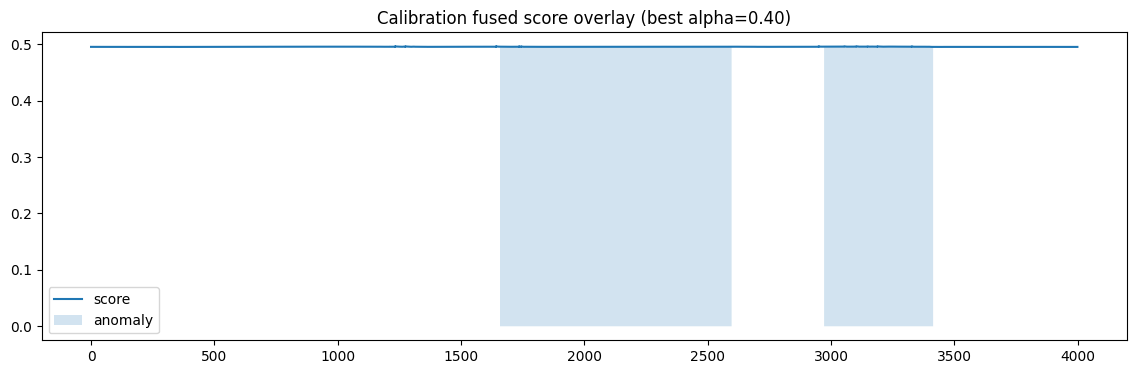

(2026-04-06 23:20:21,019) [INFO]: Register evaluations
INFO:logger:Register evaluations
(2026-04-06 23:20:21,021) [INFO]: Perform evaluations. Method[FastKANAD_SVDD_AlphaTuned_Holdout], Schema[naive].
INFO:logger:Perform evaluations. Method[FastKANAD_SVDD_AlphaTuned_Holdout], Schema[naive].
(2026-04-06 23:20:21,024) [INFO]:     [Load Data (All)] DataSets: SWaT_HybridHoldout 
INFO:logger:    [Load Data (All)] DataSets: SWaT_HybridHoldout 
(2026-04-06 23:20:21,096) [INFO]:     [FastKANAD_SVDD_AlphaTuned_Holdout] Eval dataset SWaT_HybridHoldout <<<
INFO:logger:    [FastKANAD_SVDD_AlphaTuned_Holdout] Eval dataset SWaT_HybridHoldout <<<
(2026-04-06 23:20:21,097) [INFO]:         [SWaT_HybridHoldout] Using default margins (0, 5)
INFO:logger:        [SWaT_HybridHoldout] Using default margins (0, 5)


In [ ]:

# Cell 10 — Run the EasyTSAD experiment on the holdout dataset

gctrl = TSADController()

gctrl.set_dataset(
    dataset_type="MTS",
    dirname="/content/KAN-AD/datasets",
    datasets=[CUSTOM_DATASET],
)

METHOD_NAME = "FastKANAD_SharedLatentSVDD_AlphaTuned_Holdout"
TRAINING_SCHEMA = "naive"

gctrl.run_exps(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
    cfg_path="/content/KAN-AD/kanad/config_fastkanad_sharedlatent_svdd_alpha_holdout.toml",
)

gctrl.set_evals([
    PointF1PA(),
    EventF1PA(mode="squeeze"),
    PointKthF1PA(k=5),
    PointAuprcPA(),
])

gctrl.do_evals(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
)


In [ ]:

# Cell 11 — Load and display EasyTSAD evaluation results

BASE_EVAL = "/content/KAN-AD/Results/Evals"
if not os.path.exists(BASE_EVAL):
    BASE_EVAL = "/content/KAN-AD/KAN-AD/Results/Evals"

avg_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "avg.json"), recursive=True)
all_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "all.json"), recursive=True)

print("Found avg.json:", avg_files)
print("Found all.json:", all_files)

assert avg_files, "avg.json not found"
assert all_files, "all.json not found"

avg_path = avg_files[0]
all_path = all_files[0]

with open(avg_path, "r") as f:
    avg = json.load(f)

with open(all_path, "r") as f:
    all_scores = json.load(f)

print("\n=== AVERAGE RESULTS (holdout final test) ===")
for k, v in avg.items():
    print(f"{k}: {v}")

print("\n=== PER-SERIES RESULTS ===")
print("Number of series:", len(all_scores))
if len(all_scores) > 0:
    print("Example entry:", list(all_scores.items())[0])

Found avg.json: ['/content/KAN-AD/Results/Evals/FastKANAD_SVDD_AlphaTuned_Holdout/naive/SWaT_HybridHoldout/avg.json']
Found all.json: ['/content/KAN-AD/Results/Evals/FastKANAD_SVDD_AlphaTuned_Holdout/naive/SWaT_HybridHoldout/all.json']

=== AVERAGE RESULTS (holdout final test) ===
best f1 under pa: {'f1': 0.9445027496746563, 'precision': 0.9781961261711702, 'recall': 0.9130531826390439, 'threshold': 0.005716383457183838}
event-based f1 under pa with mode squeeze: {'f1': 0.08791208791208752, 'precision': 0.06060606060606061, 'recall': 0.16, 'threshold': 0.013203144073486328}
best f1 under 5-delay pa: {'f1': 0.32857728299815364, 'precision': 0.20165302223411816, 'recall': 0.8866546273562892, 'threshold': 0.0035185515880584717}
point-based auprc pa: 0.9308137032531792

=== PER-SERIES RESULTS ===
Number of series: 1
Example entry: ('AllInOne', {'best f1 under pa': {'f1': 0.9445027496746563, 'precision': 0.9781961261711702, 'recall': 0.9130531826390439, 'threshold': 0.005716383457183838}, '

In [ ]:

# Cell 12 — Optional: inspect runtime stats and selected alpha

BASE_RUNTIME = "/content/KAN-AD/Results/RunTime"
if not os.path.exists(BASE_RUNTIME):
    BASE_RUNTIME = "/content/KAN-AD/KAN-AD/Results/RunTime"

runtime_files = glob.glob(
    os.path.join(BASE_RUNTIME, "**", METHOD_NAME, TRAINING_SCHEMA, CUSTOM_DATASET, "*.json"),
    recursive=True
)
print("Runtime files:", runtime_files[:5])

for fp in runtime_files[:5]:
    print("\n---", fp, "---")
    try:
        print(json.dumps(json.load(open(fp, "r")), indent=2)[:3000])
    except Exception as e:
        print("Could not read:", e)

Runtime files: ['/content/KAN-AD/Results/RunTime/FastKANAD_SVDD_AlphaTuned_Holdout/naive/SWaT_HybridHoldout/time.json']

--- /content/KAN-AD/Results/RunTime/FastKANAD_SVDD_AlphaTuned_Holdout/naive/SWaT_HybridHoldout/time.json ---
{
  "train_and_valid": 1915.303283195,
  "test": 18.525563562000116
}


## Notes

- This notebook uses a **holdout-style evaluation**:
  - calibration from the first anomalous part of original SWaT test
  - final EasyTSAD metrics on the remaining tail only
- The forecasting branch uses a **FastKAN / Gaussian RBF family function** instead of the original Fourier family.
- Alpha is tuned directly on the labeled holdout calibration split.
